# Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.black_scholes import BlackScholes
from src.hedging import DeltaHedgingSimulator
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load SPY + Option Parameters

In [2]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
mu_hat = float(returns.mean() * 252)
r = 0.03
q = 0.0

T = 0.5  # 6 months
K = S * 1.0  # ATM

print(f"{ticker} S:", S)
print(f"Annualized vol:", sigma_hat)
print(f"Option: K={K}, T={T}, r={r}, q={q}")

SPY S: 750.3300170898438
Annualized vol: 0.17120043078248076
Option: K=750.3300170898438, T=0.5, r=0.03, q=0.0


# Black-Scholes Reference Price

In [3]:
bs = BlackScholes(S, K, T, r, sigma_hat, q=q)
bs_price = bs.call_price()
bs_delta = bs.delta('call')

print(f"Black-Scholes Call Price: {bs_price:.4f}")
print(f"Black-Scholes Delta: {bs_delta:.4f}")

Black-Scholes Call Price: 41.8060
Black-Scholes Delta: 0.5732


# Delta Hedging Simulation w/ Daily Rebalancing

In [4]:
sim_daily = DeltaHedgingSimulator(
    option=bs,
    n_paths=1000,
    transaction_cost_bps=5,
    rebalance_step=1/252,  # daily
    seed=42
)

pnl_daily = sim_daily.run()

print(f"\nDaily Rebalancing:")
print(f"  Mean P&L: {pnl_daily.mean():.4f}")
print(f"  Std P&L: {pnl_daily.std():.4f}")
print(f"  95% CI: [{pnl_daily.quantile(0.05):.4f}, {pnl_daily.quantile(0.95):.4f}]")


Daily Rebalancing:
  Mean P&L: -1.4364
  Std P&L: 2.7043
  95% CI: [-6.1877, 2.4352]


# Delta Hedging Simulation w/ Weekly Rebalancing

In [5]:
sim_weekly = DeltaHedgingSimulator(
    option=bs,
    n_paths=1000,
    transaction_cost_bps=5,
    rebalance_step=5/252,  # weekly (5 days)
    seed=42
)

pnl_weekly = sim_weekly.run()

print(f"\nWeekly Rebalancing:")
print(f"  Mean P&L: {pnl_weekly.mean():.4f}")
print(f"  Std P&L: {pnl_weekly.std():.4f}")
print(f"  95% CI: [{pnl_weekly.quantile(0.05):.4f}, {pnl_weekly.quantile(0.95):.4f}]")


Weekly Rebalancing:
  Mean P&L: -0.8140
  Std P&L: 5.8941
  95% CI: [-11.2495, 8.6375]


# Delta Hedging Simulation w/ Monthly Rebalancing

In [6]:
sim_monthly = DeltaHedgingSimulator(
    option=bs,
    n_paths=1000,
    transaction_cost_bps=5,
    rebalance_step=21/252,  # monthly (~21 days)
    seed=42
)

pnl_monthly = sim_monthly.run()

print(f"\nMonthly Rebalancing:")
print(f"  Mean P&L: {pnl_monthly.mean():.4f}")
print(f"  Std P&L: {pnl_monthly.std():.4f}")
print(f"  95% CI: [{pnl_monthly.quantile(0.05):.4f}, {pnl_monthly.quantile(0.95):.4f}]")


Monthly Rebalancing:
  Mean P&L: -0.6475
  Std P&L: 12.0489
  95% CI: [-20.8252, 18.3342]


# Compare Hedging Errors

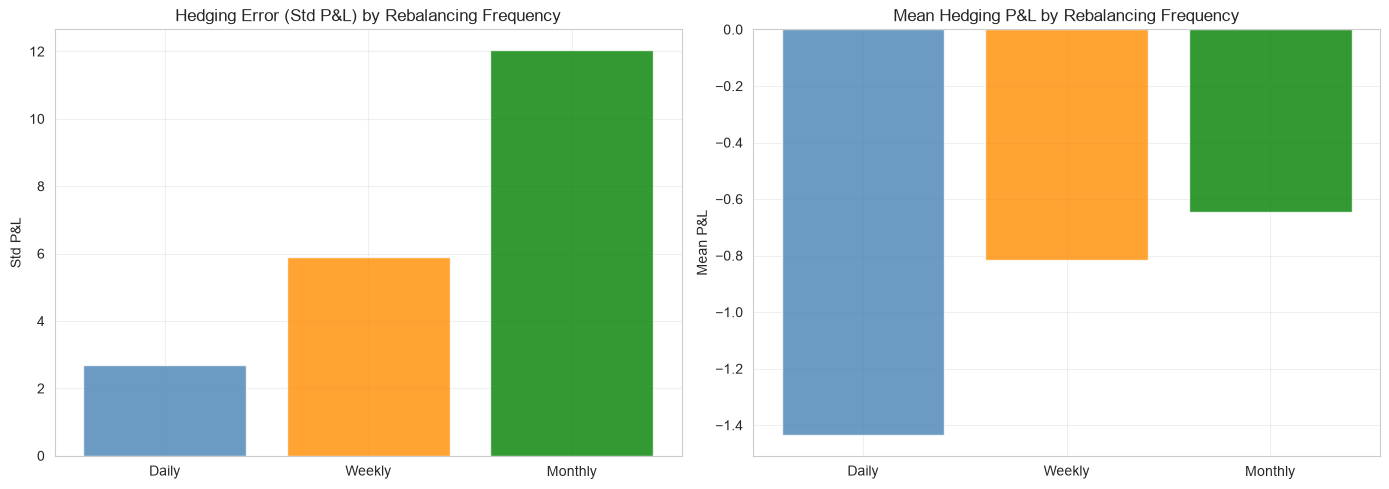


Hedging error increases as rebalancing becomes less frequent:
  Daily std: 2.7043
  Weekly std: 5.8941 (118.0% higher)
  Monthly std: 12.0489 (345.5% higher)


In [7]:
freq_labels = ['Daily', 'Weekly', 'Monthly']
freq_stds = [pnl_daily.std(), pnl_weekly.std(), pnl_monthly.std()]
freq_means = [pnl_daily.mean(), pnl_weekly.mean(), pnl_monthly.mean()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(freq_labels, freq_stds, color=['steelblue', 'darkorange', 'green'], alpha=0.8)
axes[0].set_ylabel('Std P&L')
axes[0].set_title('Hedging Error (Std P&L) by Rebalancing Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].bar(freq_labels, freq_means, color=['steelblue', 'darkorange', 'green'], alpha=0.8)
axes[1].set_ylabel('Mean P&L')
axes[1].set_title('Mean Hedging P&L by Rebalancing Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nHedging error increases as rebalancing becomes less frequent:")
print(f"  Daily std: {pnl_daily.std():.4f}")
print(f"  Weekly std: {pnl_weekly.std():.4f} ({(pnl_weekly.std()/pnl_daily.std()-1)*100:.1f}% higher)")
print(f"  Monthly std: {pnl_monthly.std():.4f} ({(pnl_monthly.std()/pnl_daily.std()-1)*100:.1f}% higher)")

# P&L Distribution Histograms

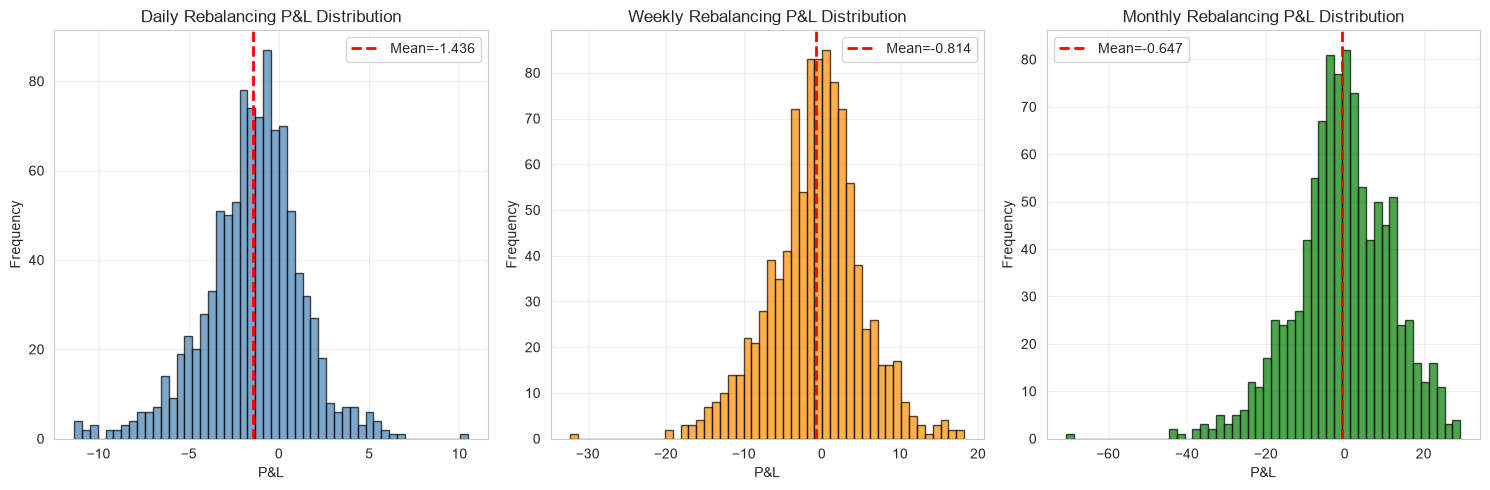

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(pnl_daily, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('P&L')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Daily Rebalancing P&L Distribution')
axes[0].axvline(pnl_daily.mean(), color='red', lw=2, linestyle='--', label=f'Mean={pnl_daily.mean():.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(pnl_weekly, bins=50, color='darkorange', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('P&L')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Weekly Rebalancing P&L Distribution')
axes[1].axvline(pnl_weekly.mean(), color='red', lw=2, linestyle='--', label=f'Mean={pnl_weekly.mean():.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(pnl_monthly, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('P&L')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Monthly Rebalancing P&L Distribution')
axes[2].axvline(pnl_monthly.mean(), color='red', lw=2, linestyle='--', label=f'Mean={pnl_monthly.mean():.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hedging Error Analysis Summary

In [9]:
summary = pd.DataFrame({
    'Frequency': freq_labels,
    'Rebalance_Step': [1/252, 5/252, 21/252],
    'Mean_PnL': freq_means,
    'Std_PnL': freq_stds,
    'Q5': [pnl_daily.quantile(0.05), pnl_weekly.quantile(0.05), pnl_monthly.quantile(0.05)],
    'Q95': [pnl_daily.quantile(0.95), pnl_weekly.quantile(0.95), pnl_monthly.quantile(0.95)]
})

print("\nHedging Error Analysis Summary:")
print(summary.to_string(index=False))


Hedging Error Analysis Summary:
Frequency  Rebalance_Step  Mean_PnL   Std_PnL         Q5       Q95
    Daily        0.003968 -1.436417  2.704286  -6.187681  2.435167
   Weekly        0.019841 -0.813964  5.894108 -11.249502  8.637550
  Monthly        0.083333 -0.647498 12.048901 -20.825247 18.334232
